Finnhub: d4m5t5hr01qjidhtok10d4m5t5hr01qjidhtok1g

In [2]:
!pip install finnhub

ERROR: Could not find a version that satisfies the requirement finnhub (from versions: none)
ERROR: No matching distribution found for finnhub


In [1]:
import os, time, hashlib
from datetime import datetime, timedelta
import pandas as pd, numpy as np
import finnhub, requests, yfinance as yf
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax
from pandas.tseries.offsets import BDay

In [13]:
# ------------------- CONFIG -------------------

# FINNHUB_API_KEY = "d2arrjpr01qgk9ugd2ugd2arrjpr01qgk9ugd2v0"
# MARKETAUX_API_KEY = "3Ej6emn1jO1MzOjziTsrCacnbQvx6pjueugwiMb4"
SYMBOL = "NVDA"
CUTOVER_DATE = datetime(2024, 8, 28).date()  # use Finnhub on or after
YEAR_START = "2023-07-01"
YEAR_END = "2025-08-01"
LAG_DAYS = [0, 1, 3, 7, 14]
OUT_DIR = "./outputs"
os.makedirs(OUT_DIR, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# API endpoints
MARKETAUX_URL = "https://api.marketaux.com/v1/news/all"

# ------------------- INIT CLIENT -------------------

# finnhub_client = finnhub.Client(api_key=FINNHUB_API_KEY)

In [ ]:
# ------------------- 1) FETCH NEWS -------------------

all_news = []
start = datetime.strptime(YEAR_START, "%Y-%m-%d")
end = datetime.strptime(YEAR_END, "%Y-%m-%d")
delta = timedelta(days=7)

print("Fetching NVDA news using Marketaux (before cutover) and Finnhub (after)...")

while start <= end:
    batch_end = min(start + delta, end)
    date_from, date_to = start.date(), batch_end.date()

    #  if before cutoff date — use Marketaux
    if date_to < CUTOVER_DATE:
        # Marketaux request
        params = {
            "api_token": MARKETAUX_API_KEY,
            "symbols": SYMBOL,
            "published_after": f"{date_from}T00:00:00",
            "published_before": f"{date_to}T23:59:59",
            "limit": 1000
        }
        try:
            resp = requests.get(MARKETAUX_URL, params=params, timeout=10)
            resp.raise_for_status()
            data = resp.json().get("data", [])
            print(f"Marketaux: {len(data)} articles {date_from}→{date_to}")
            for a in data:
                all_news.append({
                    "id": a["uuid"],
                    "timestamp": a["published_at"],
                    "headline": a["title"],
                    "summary": a["description"],
                    "url": a["url"],
                    "source": "marketaux"
                })
        except Exception as e:
            print(f"Marketaux error {date_from}→{date_to}: {e}")

    #  if on/after cutoff date — use Finnhub
    else:
        try:
            fh = finnhub_client.company_news(SYMBOL, _from=str(date_from), to=str(date_to))
            print(f"Finnhub: {len(fh)} articles {date_from}→{date_to}")
            for a in fh:
                all_news.append({
                    "id": a["id"],
                    "timestamp": pd.to_datetime(a["datetime"], unit="s", utc=True),
                    "headline": a["headline"],
                    "summary": a.get("summary", ""),
                    "url": a.get("url", ""),
                    "source": "finnhub"
                })
        except Exception as e:
            print(f"Finnhub error {date_from}→{date_to}: {e}")

    start = batch_end + timedelta(days=1)
    time.sleep(0.3)

# ------------------- Deduplicate & Normalize -------------------

df = pd.DataFrame(all_news)
# hash headline+summary+timestamp
df["ts_str"] = df["timestamp"].astype(str)
df["hash"] = (df["headline"].fillna("") + df["summary"].fillna("") + df["ts_str"]).apply(
    lambda x: hashlib.sha1(x.encode()).hexdigest()
)
df = df.drop_duplicates(subset=["hash"]).reset_index(drop=True)
df["published_at"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
df = df.dropna(subset=["published_at"])
df["pub_date"] = df["published_at"].dt.date
df["text"] = (df["headline"] + ". " + df["summary"]).str.strip()

print(f"Total news after deduplication: {len(df)}")
print("Date range:", df['pub_date'].min(), "→", df['pub_date'].max())

df.to_csv(os.path.join(OUT_DIR, "news_combined.csv"), index=False)

In [ ]:
# ------------------- 2) Sentiment Scoring -------------------

print("Scoring sentiment (FinBERT)...")
tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert").to(DEVICE)

def score(text):
    if not text:
        return (0,0,1,0)
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512).to(DEVICE)
    with torch.no_grad():
        out = model(**inputs)
    neg, neu, pos = softmax(out.logits.cpu().numpy()[0])
    return pos-neg, pos, neu, neg

sent = df["text"].apply(lambda t: pd.Series(score(t), index=["sent_net","sent_pos","sent_neu","sent_neg"]))
df = pd.concat([df, sent], axis=1)
df.to_csv(os.path.join(OUT_DIR, "news_with_sentiment.csv"), index=False)
print("Sentiment scoring done.")

In [ ]:
# ------------------- 3) Fetch Prices -------------------

start_dt = (pd.to_datetime(YEAR_START) - timedelta(days=5)).strftime("%Y-%m-%d")
end_price = df["pub_date"].max() + BDay(max(LAG_DAYS)+5)
print("Fetching historical prices:", start_dt, "→", end_price.date())
prices = yf.download(SYMBOL, start=start_dt, end=end_price.strftime("%Y-%m-%d"), interval="1d")
prices.reset_index(inplace=True)
prices["date"] = pd.to_datetime(prices["Date"]).dt.date
prices = prices[["date","Open","High","Low","Close","Volume"]]
prices.to_csv(os.path.join(OUT_DIR, "price_data.csv"), index=False)
print("Price data saved.")

# Next: compute lags, directional labels, correlation, etc. (unchanged)

In [14]:
from scipy import stats
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [6]:
# -------------------------
# 4) Compute lagged pct changes per news article
# -------------------------

# Use price DataFrame saved earlier
df_price = prices.copy()
df_price["date"] = pd.to_datetime(df_price["date"])
df_price = df_price.sort_values("date").reset_index(drop=True)
trading_dates = list(sorted(df_price["date"].unique()))

def get_trading_date_on_or_after(input_date):
    input_date = pd.Timestamp(input_date)
    for d in trading_dates:
        if d >= input_date:
            return d
    return None

def get_close_on_date(date):
    match = df_price.loc[df_price["date"] == date, "Close"]
    if len(match) == 0:
        return None
    return float(match.iloc[0])

def add_trading_days(start_date, days):
    if start_date not in trading_dates:
        start_date = get_trading_date_on_or_after(start_date)
    if start_date is None:
        return None
    try:
        start_idx = trading_dates.index(start_date)
    except ValueError:
        return None
    target_idx = start_idx + days
    if target_idx >= len(trading_dates):
        return None
    return trading_dates[target_idx]

records = []
price_min_date = df_price["date"].min()
price_max_date = df_price["date"].max()
print(f"Price data covers from {price_min_date.date()} to {price_max_date.date()}")

for _, r in df.iterrows():
    pub_date = pd.to_datetime(r["pub_date"])
    if pub_date < price_min_date:
        print(f"Warning: News date {pub_date.date()} before price data start {price_min_date.date()}. Skipping.")
        continue
    if pub_date > price_max_date:
        print(f"Warning: News date {pub_date.date()} after price data end {price_max_date.date()}. Skipping.")
        continue

    base_td = get_trading_date_on_or_after(pub_date)
    if base_td is None:
        print(f"Warning: No trading date found on/after news date {pub_date.date()}. Skipping.")
        continue
    base_close = get_close_on_date(base_td)
    if base_close is None:
        print(f"Warning: No close price for base trading date {base_td.date()}. Skipping.")
        continue

    rec = {
        "id": r.get("id", None),
        "published_at": r.get("published_at", None),
        "pub_date": pub_date,
        "base_trading_date": base_td,
        "base_close": base_close,
        "sent_net": r["sent_net"],
        "sent_pos": r["sent_pos"],
        "sent_neu": r["sent_neu"],
        "sent_neg": r["sent_neg"],
        "headline": r.get("headline", ""),
        "url": r.get("url", ""),
        "source": r.get("source", "")
    }

    for lag in LAG_DAYS:
        target_date = add_trading_days(base_td, lag)
        if target_date is None:
            print(f"Note: Lag {lag}d out of range for article on {pub_date.date()}.")
            rec[f"close_{lag}d"] = np.nan
            rec[f"pct_change_{lag}d"] = np.nan
            rec[f"trading_date_{lag}d"] = None
            continue

        close_price = get_close_on_date(target_date)
        if close_price is None:
            print(f"Warning: No price for lag {lag}d date {target_date.date()} (article {pub_date.date()}).")
            rec[f"close_{lag}d"] = np.nan
            rec[f"pct_change_{lag}d"] = np.nan
            rec[f"trading_date_{lag}d"] = None
            continue

        rec[f"close_{lag}d"] = close_price
        rec[f"pct_change_{lag}d"] = (close_price - base_close) / base_close
        rec[f"trading_date_{lag}d"] = target_date

    records.append(rec)

df_results = pd.DataFrame(records)
df_results.to_csv(os.path.join(OUT_DIR, "nvda_news_lagged_results.csv"), index=False)
print(f"Saved per-article lagged results. Processed articles: {len(df_results)}")

NameError: name 'prices' is not defined

In [29]:
# ================================
# Standalone Step 4: recompute lagged pct changes
# using existing price_data.csv and news_with_sentiment.csv
# ================================
import os
import numpy as np
import pandas as pd
from datetime import datetime

OUT_DIR = "./outputs"
LAG_DAYS = [1, 3, 7, 14, 30]

price_path = os.path.join(OUT_DIR, "price_data.csv")
news_sent_path = os.path.join(OUT_DIR, "news_with_sentiment.csv")

df_price = pd.read_csv(price_path)
df_price["date"] = pd.to_datetime(df_price["date"])
df_price = df_price.sort_values("date").reset_index(drop=True)

df = pd.read_csv(news_sent_path)
df["pub_date"] = pd.to_datetime(df["pub_date"])

trading_dates = list(sorted(df_price["date"].unique()))

def get_trading_date_on_or_after(input_date):
    input_date = pd.Timestamp(input_date)
    for d in trading_dates:
        if d >= input_date:
            return d
    return None

def get_close_on_date(date):
    match = df_price.loc[df_price["date"] == date, "Close"]
    if len(match) == 0:
        return None
    return float(match.iloc[0])

def add_trading_days(start_date, days):
    if start_date not in trading_dates:
        start_date = get_trading_date_on_or_after(start_date)
    if start_date is None:
        return None
    try:
        start_idx = trading_dates.index(start_date)
    except ValueError:
        return None
    target_idx = start_idx + days
    if target_idx >= len(trading_dates):
        return None
    return trading_dates[target_idx]

records = []
price_min_date = df_price["date"].min()
price_max_date = df_price["date"].max()
print(f"Price data covers from {price_min_date.date()} to {price_max_date.date()}")

for _, r in df.iterrows():
    pub_date = pd.to_datetime(r["pub_date"])
    if pub_date < price_min_date or pub_date > price_max_date:
        continue

    base_td = get_trading_date_on_or_after(pub_date)
    if base_td is None:
        continue
    base_close = get_close_on_date(base_td)
    if base_close is None:
        continue

    rec = {
        "id": r.get("id", None),
        "published_at": r.get("published_at", None),
        "pub_date": pub_date,
        "base_trading_date": base_td,
        "base_close": base_close,
        "sent_net": r["sent_net"],
        "sent_pos": r["sent_pos"],
        "sent_neu": r["sent_neu"],
        "sent_neg": r["sent_neg"],
        "headline": r.get("headline", ""),
        "url": r.get("url", ""),
        "source": r.get("source", "")
    }

    for lag in LAG_DAYS:
        target_date = add_trading_days(base_td, lag)
        if target_date is None:
            rec[f"close_{lag}d"] = np.nan
            rec[f"pct_change_{lag}d"] = np.nan
            rec[f"trading_date_{lag}d"] = None
            continue

        close_price = get_close_on_date(target_date)
        if close_price is None:
            rec[f"close_{lag}d"] = np.nan
            rec[f"pct_change_{lag}d"] = np.nan
            rec[f"trading_date_{lag}d"] = None
            continue

        rec[f"close_{lag}d"] = close_price
        rec[f"pct_change_{lag}d"] = (close_price - base_close) / base_close
        rec[f"trading_date_{lag}d"] = target_date

    records.append(rec)

df_results = pd.DataFrame(records)
out_path = os.path.join(OUT_DIR, "nvda_news_lagged_results.csv")
df_results.to_csv(out_path, index=False)
print(f"Saved per-article lagged results -> {out_path}, Processed articles: {len(df_results)}")

Price data covers from 2023-06-26 to 2025-09-15
Saved per-article lagged results -> ./outputs/nvda_news_lagged_results.csv, Processed articles: 8779


In [7]:
# -------------------------
# 5) Analysis: correlation, regression, directional accuracy
# -------------------------
print("Analyzing results by lag...")
summary_rows = []

for lag in LAG_DAYS:
    col = f"pct_change_{lag}d"

    if "sent_net" not in df_results.columns or col not in df_results.columns:
        print(f"Skipping lag {lag}d — missing 'sent_net' or '{col}' in df_results.")
        continue

    tmp = df_results[["sent_net", col]].dropna()
    n = len(tmp)

    if n >= 5:
        r_val, p_val = stats.pearsonr(tmp["sent_net"], tmp[col])
        X = tmp[["sent_net"]].values.reshape(-1, 1)
        y = tmp[col].values
        lr = LinearRegression().fit(X, y)
        coef = float(lr.coef_[0])
        intercept = float(lr.intercept_)
        r2 = float(lr.score(X, y))
    else:
        r_val = p_val = coef = intercept = r2 = np.nan

    tmp_dir = tmp.assign(
        sent_dir=np.sign(tmp["sent_net"]),
        price_dir=np.sign(tmp[col])
    )
    tmp_dir = tmp_dir[tmp_dir["sent_dir"] != 0]
    accuracy = (tmp_dir["sent_dir"] == tmp_dir["price_dir"]).mean() if len(tmp_dir) > 0 else np.nan

    summary_rows.append({
        "lag_days": lag,
        "n": n,
        "pearson_r": r_val,
        "p_value": p_val,
        "reg_coef": coef,
        "reg_intercept": intercept,
        "reg_r2": r2,
        "directional_accuracy": accuracy
    })

df_summary = pd.DataFrame(summary_rows).sort_values("lag_days")
if not df_summary.empty:
    summary_csv = os.path.join(OUT_DIR, "nvda_lag_summary.csv")
    df_summary.to_csv(summary_csv, index=False)
    print("Saved lag summary ->", summary_csv)
    print(df_summary)
else:
    print("No valid lag results to save.")

Analyzing results by lag...


NameError: name 'df_results' is not defined

In [31]:
# ================================
# Standalone Step 5: Analysis using existing lag file
# (no need to rerun steps 1–3 if CSVs already exist)
# ================================
import os
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LinearRegression

OUT_DIR = "./outputs"

# --- Load precomputed lagged results ---
lag_file = os.path.join(OUT_DIR, "nvda_news_lagged_results.csv")
if not os.path.exists(lag_file):
    raise FileNotFoundError(
        f"{lag_file} not found. You must run steps 1–4 at least once to create it."
    )

df_results = pd.read_csv(lag_file)

# Optional: ensure numeric types
df_results["sent_net"] = pd.to_numeric(df_results["sent_net"], errors="coerce")
for lag in LAG_DAYS:
    col = f"pct_change_{lag}d"
    if col in df_results.columns:
        df_results[col] = pd.to_numeric(df_results[col], errors="coerce")

print("Analyzing results by lag...")
summary_rows = []

for lag in LAG_DAYS:
    col = f"pct_change_{lag}d"

    if "sent_net" not in df_results.columns or col not in df_results.columns:
        print(f"Skipping lag {lag}d — missing 'sent_net' or '{col}' in df_results.")
        continue

    tmp = df_results[["sent_net", col]].dropna()
    n = len(tmp)

    if n >= 5:
        r_val, p_val = stats.pearsonr(tmp["sent_net"], tmp[col])
        X = tmp[["sent_net"]].values.reshape(-1, 1)
        y = tmp[col].values
        lr = LinearRegression().fit(X, y)
        coef = float(lr.coef_[0])
        intercept = float(lr.intercept_)
        r2 = float(lr.score(X, y))
    else:
        r_val = p_val = coef = intercept = r2 = np.nan

    tmp_dir = tmp.assign(
        sent_dir=np.sign(tmp["sent_net"]),
        price_dir=np.sign(tmp[col])
    )
    tmp_dir = tmp_dir[tmp_dir["sent_dir"] != 0]
    accuracy = (tmp_dir["sent_dir"] == tmp_dir["price_dir"]).mean() if len(tmp_dir) > 0 else np.nan

    summary_rows.append({
        "lag_days": lag,
        "n": n,
        "pearson_r": r_val,
        "p_value": p_val,
        "reg_coef": coef,
        "reg_intercept": intercept,
        "reg_r2": r2,
        "directional_accuracy": accuracy
    })

df_summary = pd.DataFrame(summary_rows).sort_values("lag_days")
if not df_summary.empty:
    summary_csv = os.path.join(OUT_DIR, "nvda_lag_summary.csv")
    df_summary.to_csv(summary_csv, index=False)
    print("Saved lag summary ->", summary_csv)
    print(df_summary)
else:
    print("No valid lag results to save.")

Analyzing results by lag...
Saved lag summary -> ./outputs/nvda_lag_summary.csv
   lag_days     n  pearson_r   p_value  reg_coef  reg_intercept    reg_r2  \
0         1  8779  -0.017746  0.096380 -0.000903       0.002384  0.000315   
1         3  8779   0.008597  0.420572  0.000767       0.008689  0.000074   
2         7  8779   0.005073  0.634634  0.000565       0.026118  0.000026   
3        14  8779  -0.020580  0.053826 -0.003234       0.036015  0.000424   
4        30  8779  -0.021023  0.048871 -0.005260       0.071540  0.000442   

   directional_accuracy  
0              0.500854  
1              0.504499  
2              0.549493  
3              0.526825  
4              0.497893  


In [33]:
# -------------------------
# 6) Compute per-article best lag
# -------------------------
def best_lag_info(row):
    vals = row[[f"pct_change_{lag}d" for lag in LAG_DAYS]].abs()
    vals = vals.dropna()
    if vals.empty:
        return (None, np.nan)
    best_col = vals.idxmax()
    best_lag = int(best_col.split("_")[2].replace("d",""))
    best_val = row[best_col]
    return (best_lag, best_val)

df_results["best_lag_days"] = df_results.apply(lambda r: best_lag_info(r)[0], axis=1)
df_results["best_lag_pct_change"] = df_results.apply(lambda r: best_lag_info(r)[1], axis=1)
df_results.to_csv(os.path.join(OUT_DIR, "nvda_news_lagged_results_with_bestlag.csv"), index=False)
print("Saved per-article best-lag file.")

Saved per-article best-lag file.


In [34]:
# -------------------------
# 7) Plots
# -------------------------
plt.figure(figsize=(8,5))
plt.plot(df_summary["lag_days"], df_summary["pearson_r"], marker="o")
plt.xlabel("Lag after news (days)")
plt.ylabel("Pearson correlation (sent_net vs pct_change)")
plt.title("NVDA: sentiment vs pct change correlation by lag")
plt.grid(True)
plt.savefig(os.path.join(OUT_DIR, "correlation_vs_lag.png"), dpi=200)
plt.close()

plt.figure(figsize=(8,5))
plt.bar(df_summary["lag_days"].astype(str), df_summary["directional_accuracy"])
plt.xlabel("Lag (days)")
plt.ylabel("Directional accuracy (fraction)")
plt.title("Direction accuracy of sentiment prediction by lag")
plt.grid(axis="y")
plt.savefig(os.path.join(OUT_DIR, "directional_accuracy_by_lag.png"), dpi=200)
plt.close()

print("Plots saved in", OUT_DIR)
print("Done.")

Plots saved in ./outputs
Done.


In [36]:
# --------- load prerequisites from disk (so we don't need steps 1–3) ---------
df_results = pd.read_csv(os.path.join(OUT_DIR, "nvda_news_lagged_results.csv"))
df_price   = pd.read_csv(os.path.join(OUT_DIR, "price_data.csv"))

In [39]:
# ================================
# 8) FEATURE ENGINEERING (standalone daily panel)
# ================================
import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

# --- Load from saved CSVs (no need to rerun steps 1–3) ---
price_file = os.path.join(OUT_DIR, "price_data.csv")
lags_file  = os.path.join(OUT_DIR, "nvda_news_lagged_results.csv")

df_price = pd.read_csv(price_file)
df_results = pd.read_csv(lags_file)

# --- Basic cleaning / typing ---
# Dates
df_price["date"] = pd.to_datetime(df_price["date"])
df_results["pub_date"] = pd.to_datetime(df_results["pub_date"])

# Numeric price columns
price_num_cols = ["Open", "High", "Low", "Close", "Volume"]
for c in price_num_cols:
    if c in df_price.columns:
        df_price[c] = pd.to_numeric(df_price[c], errors="coerce")

# Numeric sentiment columns (if present)
for c in ["sent_net", "sent_pos", "sent_neu", "sent_neg"]:
    if c in df_results.columns:
        df_results[c] = pd.to_numeric(df_results[c], errors="coerce")

# --- aggregate daily sentiment from articles ---
df_results["pub_date"] = df_results["pub_date"].dt.normalize()

news_day = (
    df_results
    .groupby("pub_date")
    .agg(
        sent_net_mean=("sent_net", "mean"),
        sent_net_sum=("sent_net", "sum"),
        sent_pos_mean=("sent_pos", "mean"),
        sent_neg_mean=("sent_neg", "mean"),
        n_articles=("id", "count")
    )
    .sort_index()
    .reset_index()
)

# --- price features ---
px = df_price.copy()
px["date"] = px["date"].dt.normalize()
px = px.sort_values("date").rename(columns={"Close": "close"}).set_index("date")

# returns & vol
px["ret_1d"]  = px["close"].pct_change(1)
px["ret_5d"]  = px["close"].pct_change(5)
px["ret_10d"] = px["close"].pct_change(10)
px["vol_10d"] = px["ret_1d"].rolling(10).std()
px["vol_20d"] = px["ret_1d"].rolling(20).std()

# flatten multiindex columns in px (defensive)
if isinstance(px.columns, pd.MultiIndex):
    px.columns = ["_".join([str(c) for c in col]).strip("_") for col in px.columns]

# ensure news_day index is 'date'
news_day = news_day.rename(columns={"pub_date": "date"}).set_index("date")

# merge features
feat = px.join(news_day, how="left")

# fill no-news days with zeros (no news signal that day)
for c in ["sent_net_mean", "sent_net_sum", "sent_pos_mean", "sent_neg_mean", "n_articles"]:
    if c in feat.columns:
        feat[c] = feat[c].fillna(0)

# --- future label horizons ---
HORIZONS = [1, 3, 5, 10]  # trading days ahead

# auto-detect close column (handles "close" or "close_NVDA" cases)
close_candidates = [c for c in feat.columns if c.startswith("close")]
if len(close_candidates) == 0:
    raise ValueError(f"No 'close*' column found in feat.columns: {feat.columns.tolist()}")
close_col = close_candidates[0]
print(f"Using close column: {close_col}")

for h in HORIZONS:
    # return over next h days
    feat[f"label_ret_{h}d"] = feat[close_col].shift(-h) / feat[close_col] - 1.0
    
    # 3-class direction label: -1, 0, +1 (with neutral band)
    band = 0.002  # +/- 0.2% as neutral band
    lab = feat[f"label_ret_{h}d"].apply(
        lambda r: 1 if r > band else (-1 if r < -band else 0)
    )
    feat[f"label_dir_{h}d"] = lab

feat = feat.dropna().copy()

print("Feature panel 'feat' ready. Shape:", feat.shape)
print("Columns:", feat.columns.tolist())

Using close column: close
Feature panel 'feat' ready. Shape: (528, 23)
Columns: ['Open', 'High', 'Low', 'close', 'Volume', 'ret_1d', 'ret_5d', 'ret_10d', 'vol_10d', 'vol_20d', 'sent_net_mean', 'sent_net_sum', 'sent_pos_mean', 'sent_neg_mean', 'n_articles', 'label_ret_1d', 'label_dir_1d', 'label_ret_3d', 'label_dir_3d', 'label_ret_5d', 'label_dir_5d', 'label_ret_10d', 'label_dir_10d']


In [40]:
# ================================
# 9) SEQUENCE DATASETS (for LSTM/Transformer)
# ================================
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, mean_absolute_error

SEQLEN = 20
PRED_H = 5   # choose horizon to train (one of HORIZONS)



feature_cols = [
    "ret_1d","ret_5d","ret_10d","vol_10d","vol_20d",
    "sent_net_mean","sent_net_sum","sent_pos_mean","sent_neg_mean","n_articles"
]
label_col = f"label_dir_{PRED_H}d"      # classification target
timing_target = f"label_ret_{PRED_H}d"  # continuous return for MAE

Xdf = feat[feature_cols].copy()
ydf = feat[[label_col, timing_target]].copy()

# scale features (fit on train folds only inside CV; here we prepare arrays)
X = Xdf.values.astype(np.float32)
y_class = ydf[label_col].values.astype(np.int64)
y_reg   = ydf[timing_target].values.astype(np.float32)

mask = y_class != 0   # remove neutral days
X = X[mask]
y_class = y_class[mask]
y_reg = y_reg[mask]




def make_sequences(X, y_class, y_reg, seq_len):
    Xs, yc, yr = [], [], []
    for i in range(len(X)-seq_len):
        Xs.append(X[i:i+seq_len])
        yc.append(y_class[i+seq_len-1])
        yr.append(y_reg[i+seq_len-1])

    if len(Xs) == 0:
        # return empty arrays safely
        return np.empty((0, seq_len, X.shape[1]), dtype=np.float32), np.array([], dtype=int), np.array([], dtype=np.float32)

    return np.stack(Xs), np.array(yc), np.array(yr)

# we will scale inside each fold to avoid leakage

Xs_tr, yc_tr, yr_tr = make_sequences(X, y_class, y_reg, SEQLEN)
print(f"Sequences shape: {Xs_tr.shape}, Classes: {yc_tr.shape}, Reg: {yr_tr.shape}")

Sequences shape: (493, 20, 10), Classes: (493,), Reg: (493,)


In [41]:
# ================================
# 10) MODELS: LSTM & Transformer (PyTorch)
# ================================
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class LSTMClassifier(nn.Module):
    def __init__(self, n_features, hidden=64, layers=1, dropout=0.1, n_classes=3):
        super().__init__()
        self.lstm = nn.LSTM(input_size=n_features, hidden_size=hidden,
                            num_layers=layers, batch_first=True, dropout=dropout if layers>1 else 0.0)
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, n_classes)
        )
        self.reg_head = nn.Sequential(
            nn.Linear(hidden, hidden//2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden//2, 1)
        )
    def forward(self, x):
        # x: [B, T, F]
        out, _ = self.lstm(x)
        h = out[:, -1, :]  # last time step output: shape (B, hidden)
        logits = self.head(h)
        reg = self.reg_head(h).squeeze(-1)  # (B,)
        return logits, reg

class TinyTransformer(nn.Module):
    def __init__(self, n_features, d_model=64, nhead=4, num_layers=2, dropout=0.1, n_classes=3):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True, dropout=dropout)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.cls = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, n_classes)
        )
        self.reg = nn.Sequential(
            nn.Linear(d_model, d_model//2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model//2, 1)
        )
    def forward(self, x):
        z = self.input_proj(x)
        z = self.encoder(z)
        h = z[:, -1, :]
        return self.cls(h), self.reg(h).squeeze(-1)

In [42]:
# ================================
# 11) TRAINING LOOP with TimeSeries CV + small grid
# ================================
def train_eval_model(model_name="lstm"):
    grids = {
        "lstm": [
            {"hidden": 64, "layers": 1, "dropout": 0.1, "lr": 1e-3, "epochs": 30, "batch": 64, "weight_decay": 1e-4},
            {"hidden": 128, "layers": 2, "dropout": 0.2, "lr": 5e-4, "epochs": 40, "batch": 64, "weight_decay": 5e-5},
            {"hidden": 256, "layers": 2, "dropout": 0.3, "lr": 1e-4, "epochs": 50, "batch": 32, "weight_decay": 1e-5},
        ],
        "transformer": [
            {"d_model": 64, "nhead": 4, "num_layers": 2, "dropout": 0.1, "lr": 1e-3, "epochs": 30, "batch": 64, "weight_decay": 1e-4},
            {"d_model": 128, "nhead": 4, "num_layers": 3, "dropout": 0.2, "lr": 5e-4, "epochs": 40, "batch": 32, "weight_decay": 5e-5},
            {"d_model": 128, "nhead": 8, "num_layers": 4, "dropout": 0.3, "lr": 1e-4, "epochs": 50, "batch": 32, "weight_decay": 1e-5},
        ]
    }
    param_grid = grids[model_name]
    tscv = TimeSeriesSplit(n_splits=5)
    best_summary = None

    for params in param_grid:
        fold_metrics = []
        fold_idx = 0
        for train_idx, test_idx in tscv.split(X):
            fold_idx += 1

            # scale on train only
            scaler = StandardScaler()
            X_tr = scaler.fit_transform(X[train_idx])
            X_te = scaler.transform(X[test_idx])

            # remove neutral days
            mask_tr = y_class[train_idx] != 0
            mask_te = y_class[test_idx] != 0

            Xs_tr, yc_tr, yr_tr = make_sequences(
                X[train_idx][mask_tr],
                y_class[train_idx][mask_tr],
                y_reg[train_idx][mask_tr],
                SEQLEN
            )
            Xs_te, yc_te, yr_te = make_sequences(
                X[test_idx][mask_te],
                y_class[test_idx][mask_te],
                y_reg[test_idx][mask_te],
                SEQLEN
            )

            if len(Xs_tr) == 0 or len(Xs_te) == 0:
                print("Skipping fold: not enough data to create sequences")
                continue

            # --- remap classes from [-1,0,1] -> [0,1,2] ---
            yc_tr_mapped = yc_tr + 1
            yc_te_mapped = yc_te + 1

            ds_tr = TensorDataset(torch.tensor(Xs_tr, dtype=torch.float32),
                                  torch.tensor(yc_tr_mapped, dtype=torch.long),
                                  torch.tensor(yr_tr, dtype=torch.float32))
            ds_te = TensorDataset(torch.tensor(Xs_te, dtype=torch.float32),
                                  torch.tensor(yc_te_mapped, dtype=torch.long),
                                  torch.tensor(yr_te, dtype=torch.float32))

            dl_tr = DataLoader(ds_tr, batch_size=params.get("batch",64), shuffle=False)
            dl_te = DataLoader(ds_te, batch_size=256, shuffle=False)

            # --- build model ---
            if model_name=="lstm":
                model = LSTMClassifier(
                    n_features=len(feature_cols),
                    hidden=params["hidden"],
                    layers=params["layers"],
                    dropout=params["dropout"],
                    n_classes=3
                ).to(device)
            else:
                model = TinyTransformer(
                    n_features=len(feature_cols),
                    d_model=params["d_model"],
                    nhead=params["nhead"],
                    num_layers=params["num_layers"],
                    dropout=params["dropout"],
                    n_classes=3
                ).to(device)

            # --- class weights ---
            classes, counts = np.unique(yc_tr_mapped, return_counts=True)
            weights = np.zeros(3, dtype=np.float32)
            for c, cnt in zip(classes, counts):
                weights[c] = 1.0 / cnt
            weights = torch.tensor(weights).to(device)
            cls_loss = nn.CrossEntropyLoss(weight=weights)
            reg_loss = nn.L1Loss()

            # --- optimizer ---
            opt = torch.optim.Adam(model.parameters(),
                                   lr=params["lr"],
                                   weight_decay=params.get("weight_decay", 0.0))

            # --- early stopping on F1 ---
            best_f1 = -1
            patience, trigger = 5, 0

            for epoch in range(params["epochs"]):
                model.train()
                for xb, yb_cls, yb_reg in dl_tr:
                    xb, yb_cls, yb_reg = xb.to(device), yb_cls.to(device), yb_reg.to(device)
                    logits, pred_reg = model(xb)
                    loss = cls_loss(logits, yb_cls) + 0.2*reg_loss(pred_reg, yb_reg)
                    opt.zero_grad()
                    loss.backward()
                    opt.step()

                # --- validation ---
                model.eval()
                yhat_cls, ytrue_cls = [], []
                yhat_reg, ytrue_reg = [], []
                with torch.no_grad():
                    for xb, yb_cls, yb_reg in dl_te:
                        xb = xb.to(device)
                        logits, pred_reg = model(xb)
                        yhat_cls.extend(torch.argmax(logits, dim=1).cpu().numpy().tolist())
                        ytrue_cls.extend(yb_cls.numpy().tolist())
                        yhat_reg.extend(pred_reg.cpu().numpy().tolist())
                        ytrue_reg.extend(yb_reg.numpy().tolist())

                val_f1 = f1_score(ytrue_cls, yhat_cls, average="macro", zero_division=0)
                if val_f1 > best_f1:
                    best_f1 = val_f1
                    best_model_state = model.state_dict()
                    trigger = 0
                else:
                    trigger += 1
                    if trigger >= patience:
                        print(f"Early stopping at epoch {epoch}")
                        break

            # restore best model for this fold
            model.load_state_dict(best_model_state)

            # --- metrics ---
            yhat_cls_orig = np.array(yhat_cls) - 1  # map back to [-1,0,1]
            prec = precision_score(ytrue_cls, yhat_cls, average="macro", zero_division=0)
            rec  = recall_score(ytrue_cls, yhat_cls, average="macro", zero_division=0)
            f1   = f1_score(ytrue_cls, yhat_cls, average="macro", zero_division=0)
            cm   = confusion_matrix(ytrue_cls, yhat_cls, labels=[0,1,2])
            mae  = mean_absolute_error(ytrue_reg, yhat_reg)
            mape = mean_absolute_percentage_error(ytrue_reg, yhat_reg)

            sign = np.where(yhat_cls_orig==1, 1, np.where(yhat_cls_orig==-1,-1,0))
            pnl = sign * np.array(ytrue_reg)
            cumret = np.nansum(pnl)

            fold_metrics.append({
                "fold": fold_idx, "acc": accuracy_score(ytrue_cls, yhat_cls),
                "prec": prec, "rec": rec, "f1": f1, "mae": mae, "mape": mape,
                "cumret_sum": cumret, "cm": cm
            })

        # --- summarize grid ---
        if len(fold_metrics) == 0:
            continue
        avg = {k: np.mean([m[k] for m in fold_metrics if k!="cm"]) for k in ["acc","prec","rec","f1","mae","mape","cumret_sum"]}
        summary = {
            "model": model_name,
            "params": params,
            "avg_acc": avg["acc"],
            "avg_prec": avg["prec"],
            "avg_rec": avg["rec"],
            "avg_f1": avg["f1"],
            "avg_mae": avg["mae"],
            "avg_mape": avg["mape"],
            "avg_cumret_sum": avg["cumret_sum"]
        }
        print(f"[{model_name.upper()}] params={params} -> "
              f"ACC {avg['acc']:.3f} | F1 {avg['f1']:.3f} | MAE {avg['mae']:.3f} | CumRet {avg['cumret_sum']:.3f}")
        if (best_summary is None) or (summary["avg_f1"] > best_summary["avg_f1"]):
            best_summary = summary

    return best_summary, fold_metrics

best_lstm, lstm_fold_metrics = train_eval_model("lstm")
best_trf, trf_fold_metrics  = train_eval_model("transformer")

print("\n=== MODEL SELECTION (by F1) ===")
print("Best LSTM:", best_lstm)
print("Best Transformer:", best_trf)

Early stopping at epoch 5
Early stopping at epoch 5
Early stopping at epoch 16
Early stopping at epoch 6
Early stopping at epoch 5
[LSTM] params={'hidden': 64, 'layers': 1, 'dropout': 0.1, 'lr': 0.001, 'epochs': 30, 'batch': 64, 'weight_decay': 0.0001} -> ACC 0.357 | F1 0.273 | MAE 0.066 | CumRet -0.952
Early stopping at epoch 5
Early stopping at epoch 7
Early stopping at epoch 5
Early stopping at epoch 5
Early stopping at epoch 10
[LSTM] params={'hidden': 128, 'layers': 2, 'dropout': 0.2, 'lr': 0.0005, 'epochs': 40, 'batch': 64, 'weight_decay': 5e-05} -> ACC 0.375 | F1 0.267 | MAE 0.072 | CumRet -0.717
Early stopping at epoch 5
Early stopping at epoch 5
Early stopping at epoch 6
Early stopping at epoch 9
Early stopping at epoch 5
[LSTM] params={'hidden': 256, 'layers': 2, 'dropout': 0.3, 'lr': 0.0001, 'epochs': 50, 'batch': 32, 'weight_decay': 1e-05} -> ACC 0.385 | F1 0.270 | MAE 0.062 | CumRet -0.648
Early stopping at epoch 5
Early stopping at epoch 10
Early stopping at epoch 7
Early

In [43]:
# ================================
# 12) HYBRID TIMING MODEL (discrete-time survival-ish)
#     Predict: probability the |return| exceeds a threshold within H days.
# ================================
from sklearn.linear_model import LogisticRegression

thr = 0.03  # 3% absolute move within PRED_H days
feat["event_within_H"] = (feat[f"label_ret_{PRED_H}d"].abs() >= thr).astype(int)

# simple lagged snapshot features (no sequences)
Xh = feat[feature_cols].values
yh = feat["event_within_H"].values

tscv = TimeSeriesSplit(n_splits=5)
best_hybrid = None
for C in [0.1, 1.0, 3.0]:
    scores = []
    for tr, te in tscv.split(Xh):
        sc = StandardScaler()
        Xtr = sc.fit_transform(Xh[tr])
        Xte = sc.transform(Xh[te])
        clf = LogisticRegression(C=C, max_iter=200, class_weight="balanced")
        clf.fit(Xtr, yh[tr])
        p = clf.predict_proba(Xte)[:,1]
        # threshold 0.5 classification for metrics, but keep it probabilistic for timing use
        yhat = (p >= 0.5).astype(int)
        scores.append(f1_score(yh[te], yhat))
    avg_f1 = float(np.mean(scores))
    print(f"[Hybrid timing] C={C} -> F1={avg_f1:.3f}")
    if (best_hybrid is None) or (avg_f1 > best_hybrid["f1"]):
        best_hybrid = {"C": C, "f1": avg_f1}

print("Best Hybrid timing:", best_hybrid)

[Hybrid timing] C=0.1 -> F1=0.571
[Hybrid timing] C=1.0 -> F1=0.571
[Hybrid timing] C=3.0 -> F1=0.576
Best Hybrid timing: {'C': 3.0, 'f1': 0.5763561009643647}


# Evaluation

In [45]:
import random
import pandas as pd
import os

summary_txt_path = os.path.join(OUT_DIR, "nvda_summary_report.txt")

with open(summary_txt_path, "w", encoding="utf-8") as f:
    def write_and_print(line=""):
        print(line)
        f.write(line + "\n")

    write_and_print("=== NVDA Stock Sentiment Impact Summary ===\n")

    # ---------------------------
    # 1) Correlation / lag summary
    # ---------------------------
    if not df_summary.empty:
        best_row = df_summary.loc[df_summary['pearson_r'].abs().idxmax()]
        best_corr_lag = int(best_row["lag_days"])
        best_corr_val = best_row["pearson_r"]

        write_and_print(
            f"Overall, the strongest correlation between news sentiment "
            f"and stock price change is at a lag of {best_corr_lag} trading days."
        )
        write_and_print(f"Correlation coefficient at this lag: {best_corr_val:.3f}\n")
    else:
        write_and_print("No valid lag correlation results to summarize.\n")

    # ---------------------------
    # 2) Example article impacts
    # ---------------------------
    # Ensure best_lag_days / best_lag_pct_change exist
    needed_cols = {"best_lag_days", "best_lag_pct_change"}
    if not needed_cols.issubset(df_results.columns):
        # try to reload from the enriched CSV if it exists
        bestlag_path = os.path.join(OUT_DIR, "nvda_news_lagged_results_with_bestlag.csv")
        if os.path.exists(bestlag_path):
            write_and_print(f"Reloading df_results from {bestlag_path} to get best-lag columns.")
            df_results = pd.read_csv(bestlag_path)
        else:
            write_and_print(
                "Per-article best lag columns not found and "
                "'nvda_news_lagged_results_with_bestlag.csv' is missing.\n"
                "Skipping example article impacts section.\n"
            )
            valid_articles = pd.DataFrame()  # empty
    # After reload attempt, check again
    if needed_cols.issubset(df_results.columns):
        valid_articles = df_results.dropna(subset=["best_lag_days", "best_lag_pct_change"])
    else:
        valid_articles = pd.DataFrame()

    write_and_print(f"Number of articles with valid impact data: {len(valid_articles)}\n")

    if len(valid_articles) == 0:
        write_and_print("No articles with valid impact data to show examples.\n")
    else:
        sample_size = min(5, len(valid_articles))
        examples = valid_articles.sample(sample_size, random_state=None)
        write_and_print(f"Showing {sample_size} example news impacts:\n")

        for _, row in examples.iterrows():
            try:
                best_lag_days = int(row["best_lag_days"])
                trading_date_col = f"trading_date_{best_lag_days}d"
                pct_change_col = f"pct_change_{best_lag_days}d"

                pub_date = pd.to_datetime(row["pub_date"]).date()
                impact_date = row.get(trading_date_col, None)
                impact_pct = row.get(pct_change_col, None)

                write_and_print(
                    f"- Lag days: "
                    f"{pd.to_datetime(impact_date).date() - pub_date if pd.notnull(impact_date) else 'N/A'}"
                )
                write_and_print(f"  News Date: {pub_date}")

                if pd.notnull(impact_date):
                    write_and_print(
                        f"  Impact Date ({best_lag_days} trading days later): "
                        f"{pd.to_datetime(impact_date).date()}"
                    )
                else:
                    write_and_print(f"  Impact Date ({best_lag_days} trading days later): N/A")

                write_and_print(f"  Headline: {row.get('headline', 'N/A')}")

                if pd.notnull(impact_pct):
                    write_and_print(f"  Price Change: {impact_pct*100:.2f}%\n")
                else:
                    write_and_print("  Price Change: N/A (no data)\n")
            except Exception as e:
                write_and_print(f"  Skipped an example due to error: {e}\n")

    # ---------------------------
    # 3) ML model results summary
    # ---------------------------
    def write_model_summary(name, result_dict, fold_metrics=None):
        write_and_print(f"\n=== {name} Model Summary ===")
        if result_dict is None:
            write_and_print("No results available.\n")
            return

        write_and_print(f"Hyperparameters: {result_dict.get('params', {})}")
        write_and_print(f"Average Accuracy: {result_dict.get('avg_acc', 0):.3f}")
        write_and_print(f"Average Precision: {result_dict.get('avg_prec', 0):.3f}")
        write_and_print(f"Average Recall: {result_dict.get('avg_rec', 0):.3f}")
        write_and_print(f"Average F1 Score: {result_dict.get('avg_f1', 0):.3f}")
        write_and_print(f"Average MAE (timing prediction): {result_dict.get('avg_mae', 0):.3f}")
        write_and_print(f"Average MAPE (timing prediction): {result_dict.get('avg_mape', 0):.2f}%")
        write_and_print(f"Cumulative pseudo-return: {result_dict.get('avg_cumret_sum', 0):.3f}")

        # Include confusion matrix if fold_metrics provided
        if fold_metrics:
            total_cm = None
            for m in fold_metrics:
                cm = m.get("cm")
                if cm is not None:
                    if total_cm is None:
                        total_cm = cm
                    else:
                        total_cm += cm
            if total_cm is not None:
                write_and_print("Aggregated Confusion Matrix (rows=true, cols=pred):")
                write_and_print(str(total_cm))
        write_and_print("")  # blank line

    write_model_summary("LSTM", best_lstm, fold_metrics=lstm_fold_metrics)
    write_model_summary("Transformer", best_trf, fold_metrics=trf_fold_metrics)

    # Hybrid timing model
    write_and_print("=== Hybrid Timing Model Summary ===")
    if best_hybrid is not None:
        write_and_print(f"Best regularization C: {best_hybrid.get('C')}")
        write_and_print(f"Average F1 score: {best_hybrid.get('f1',0):.3f}\n")
    else:
        write_and_print("No hybrid timing model results available.\n")

    # ---------------------------
    # 4) Notes
    # ---------------------------
    write_and_print(
        "Note: Price change is calculated as the percentage change in closing price "
        "relative to the closing price on or just after the news publication date."
    )
    write_and_print(
        "The impact delay (lag) indicates how many trading days after news publication "
        "the stock price shows the strongest per-article reaction."
    )
    write_and_print(
        "ML model metrics summarize predictive performance on classification of price direction "
        "and timing of movements (MAE for continuous return prediction)."
    )
    write_and_print(f"\nDetailed impact summary saved to: {summary_txt_path}")

=== NVDA Stock Sentiment Impact Summary ===

Overall, the strongest correlation between news sentiment and stock price change is at a lag of 30 trading days.
Correlation coefficient at this lag: -0.021

Reloading df_results from ./outputs/nvda_news_lagged_results_with_bestlag.csv to get best-lag columns.
Number of articles with valid impact data: 8779

Showing 5 example news impacts:

- Lag days: 43 days, 0:00:00
  News Date: 2025-04-30
  Impact Date (30 trading days later): 2025-06-12
  Headline: Franklin Global Equity Fund Q1 2025 Commentary
  Price Change: 33.13%

- Lag days: 9 days, 0:00:00
  News Date: 2024-10-21
  Impact Date (7 trading days later): 2024-10-30
  Headline: Nvidia: After Understanding This, My Only Regret Is That I Didn't Buy More
  Price Change: -3.04%

- Lag days: 21 days, 0:00:00
  News Date: 2025-02-10
  Impact Date (14 trading days later): 2025-03-03
  Headline: 3 Reasons It’s Time to Sell Some Magnificent 7 Stock
  Price Change: -14.61%

- Lag days: 44 days, 

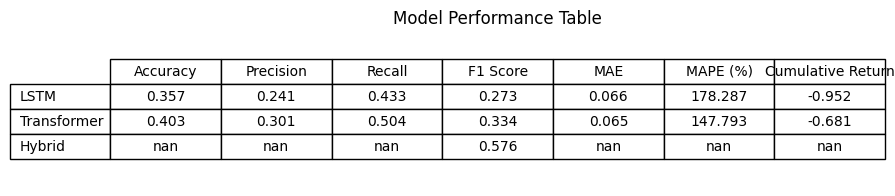

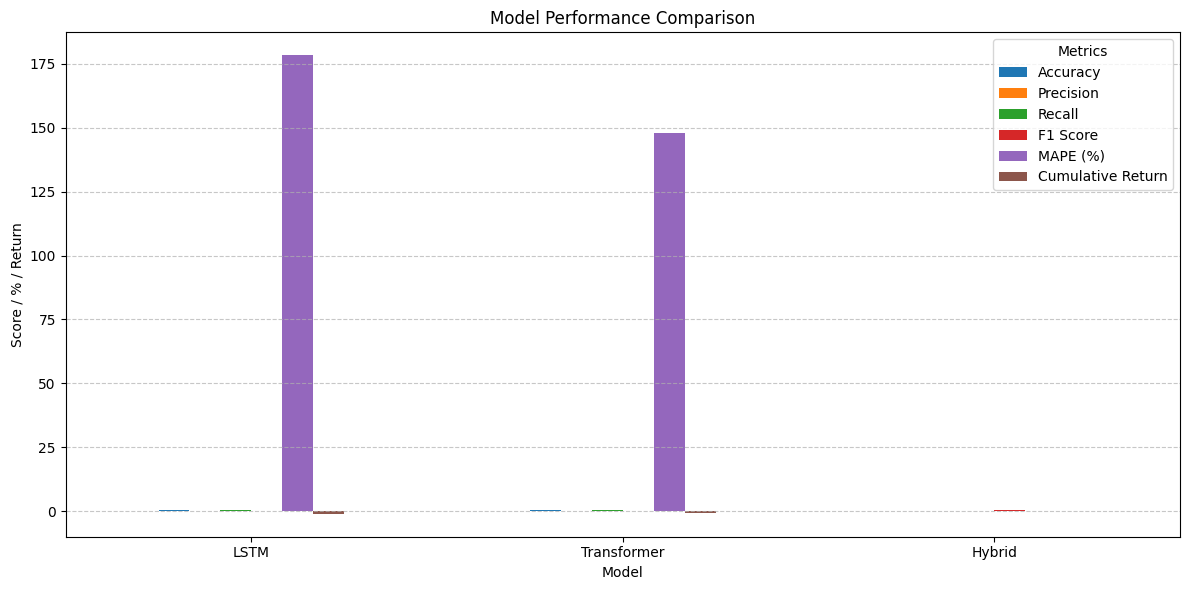

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import table

# --- Collect results dynamically ---
models = []

# LSTM
if best_lstm is not None:
    models.append({
        "Model": "LSTM",
        "Accuracy": best_lstm.get("avg_acc", 0),
        "Precision": best_lstm.get("avg_prec", 0),
        "Recall": best_lstm.get("avg_rec", 0),
        "F1 Score": best_lstm.get("avg_f1", 0),
        "MAE": best_lstm.get("avg_mae", 0),
        "MAPE (%)": best_lstm.get("avg_mape", 0),
        "Cumulative Return": best_lstm.get("avg_cumret_sum", 0)
    })

# Transformer
if best_trf is not None:
    models.append({
        "Model": "Transformer",
        "Accuracy": best_trf.get("avg_acc", 0),
        "Precision": best_trf.get("avg_prec", 0),
        "Recall": best_trf.get("avg_rec", 0),
        "F1 Score": best_trf.get("avg_f1", 0),
        "MAE": best_trf.get("avg_mae", 0),
        "MAPE (%)": best_trf.get("avg_mape", 0),
        "Cumulative Return": best_trf.get("avg_cumret_sum", 0)
    })

# Hybrid timing model (optional)
if best_hybrid is not None:
    models.append({
        "Model": "Hybrid",
        "Accuracy": None,
        "Precision": None,
        "Recall": None,
        "F1 Score": best_hybrid.get("f1", 0),
        "MAE": None,
        "MAPE (%)": None,
        "Cumulative Return": None
    })

# --- Convert to DataFrame ---
df_models = pd.DataFrame(models).set_index("Model")

# --- 1) Display graphical table ---
fig, ax = plt.subplots(figsize=(10, 2))
ax.axis("off")
tbl = table(ax, df_models.round(3), loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.5)
plt.title("Model Performance Table", fontsize=12)
plt.show()

# --- 2) Plot grouped bar chart ---
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1 Score", "MAPE (%)", "Cumulative Return"]
df_plot = df_models[metrics_to_plot]

ax = df_plot.plot(kind="bar", figsize=(12, 6))
plt.title("Model Performance Comparison")
plt.ylabel("Score / % / Return")
plt.xticks(rotation=0)
plt.legend(title="Metrics")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# Arima